ML OBLIG1

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os; os.makedirs("figures", exist_ok=True)
import seaborn as sns

df = pd.read_csv("train.csv")
print(df.shape)
print(df.isna().sum().sum())

(21263, 82)
0


Q1.1.1


In [18]:
stats = df.describe().T
stats["cv"] = stats["std"] / stats["mean"]

cols = ["mean", "std", "min", "max", "cv"]
print(stats.sort_values("std", ascending=False).head(10)[cols])
print(stats.drop("critical_temp").sort_values("cv", ascending=False).head(10)[cols])

                          mean          std       min           max        cv
range_Density      8665.438818  4097.126831  0.000000  22588.571000  0.472812
wtd_gmean_Density  3117.241110  3975.122587  0.686245  22590.000000  1.275205
gmean_Density      3460.692235  3703.256370  1.429000  22590.000000  1.070091
wtd_mean_Density   5267.188547  3221.314506  1.429000  22590.000000  0.611581
mean_Density       6111.465214  2846.785185  1.429000  22590.000000  0.465811
wtd_range_Density  2902.736814  2398.471020  0.000000  22434.160000  0.826279
std_Density        3416.910784  1673.624915  0.000000  10724.374500  0.489806
wtd_std_Density    3319.170628  1611.799629  0.000000  10410.932005  0.485603
range_fie           572.222612   309.614442  0.000000   1304.500000  0.541073
wtd_range_fie       483.517264   224.042874  0.000000   1251.855072  0.463361
                                      mean          std       min  \
wtd_gmean_ThermalConductivity    27.308061    40.191150  0.022952   
wtd_

Q 1.1.2

skew raw:   0.8602232926106779
skew log:   -1.0042645868572804
skew log1p: -0.3173279075241499


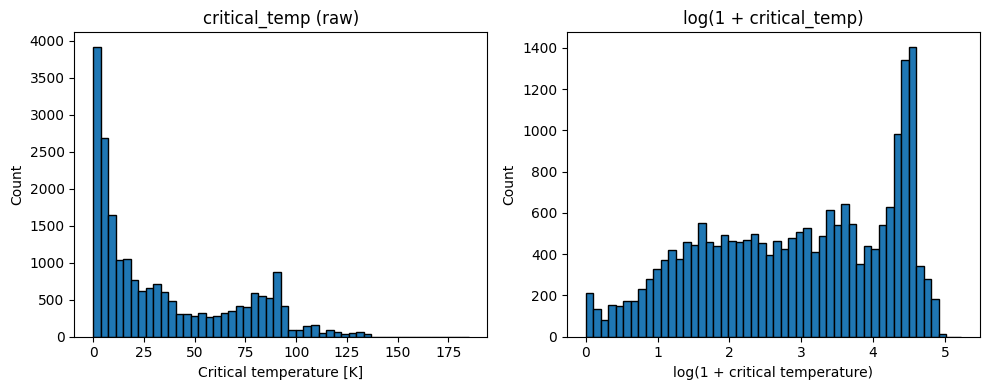

In [19]:
y = df["critical_temp"]
y_log = np.log1p(y)                  # log(1 + y)

print("skew raw:  ", y.skew())
print("skew log:  ", np.log(y).skew())
print("skew log1p:", y_log.skew())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(y, bins=50, edgecolor="black")
axes[0].set(title="critical_temp (raw)", xlabel="Critical temperature [K]", ylabel="Count")
axes[1].hist(y_log, bins=50, edgecolor="black")
axes[1].set(title="log(1 + critical_temp)", xlabel="log(1 + critical temperature)", ylabel="Count")
plt.tight_layout()
plt.savefig("figures/q112_target_distribution.pdf", bbox_inches="tight")
plt.show()

Q 1.2.1

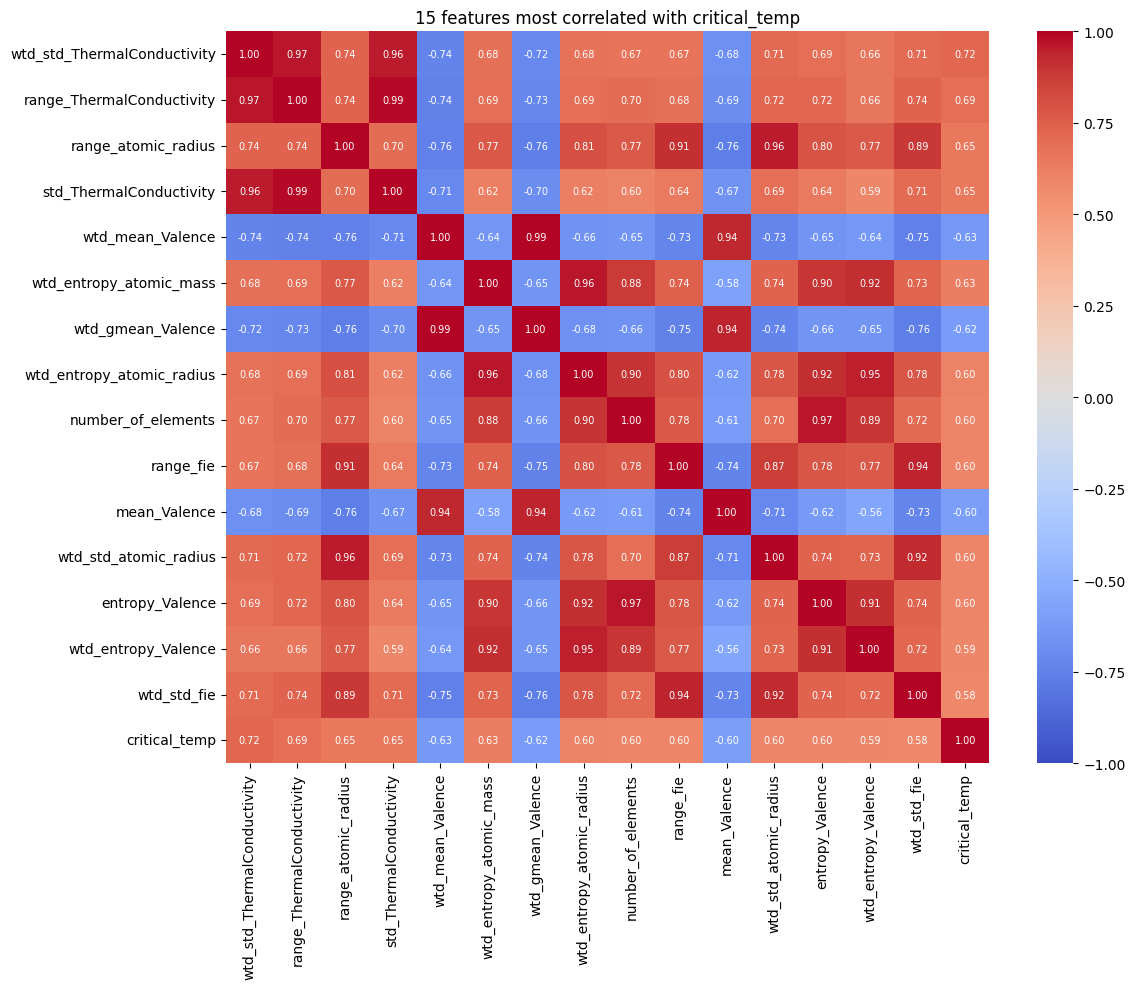

In [20]:
corr = df.corr()
target_corr = corr["critical_temp"].drop("critical_temp")
top15 = target_corr.abs().sort_values(ascending=False).head(15).index

cols = list(top15) + ["critical_temp"]
plt.figure(figsize=(12, 10))
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, annot_kws={"size": 7})
plt.title("15 features most correlated with critical_temp")
plt.tight_layout()
plt.savefig("figures/q121_heatmap.pdf", bbox_inches="tight")
plt.show()

Q 1.2.2

In [21]:
print(target_corr.sort_values(ascending=False).head(5))
print(target_corr.sort_values().head(5))

wtd_std_ThermalConductivity    0.721271
range_ThermalConductivity      0.687654
range_atomic_radius            0.653759
std_ThermalConductivity        0.653632
wtd_entropy_atomic_mass        0.626930
Name: critical_temp, dtype: float64
wtd_mean_Valence    -0.632401
wtd_gmean_Valence   -0.615653
mean_Valence        -0.600085
gmean_Valence       -0.573068
gmean_Density       -0.541684
Name: critical_temp, dtype: float64


Q 1.2.3

In [22]:
fc = df.drop(columns="critical_temp").corr()
mask = np.triu(np.ones(fc.shape, dtype=bool), k=1)
pairs = fc.where(mask).stack()
high = pairs[pairs.abs() > 0.9].sort_values(key=abs, ascending=False)

print(len(high), "pairs with |r| > 0.9")
print(high.head(10))

74 pairs with |r| > 0.9
entropy_fie                entropy_atomic_radius      0.997739
wtd_mean_Valence           wtd_gmean_Valence          0.994939
entropy_fie                entropy_Valence            0.992726
wtd_mean_fie               wtd_gmean_fie              0.992331
mean_Valence               gmean_Valence              0.989911
entropy_atomic_radius      entropy_Valence            0.989546
range_ThermalConductivity  std_ThermalConductivity    0.987867
range_FusionHeat           std_FusionHeat             0.984574
range_fie                  std_fie                    0.981628
wtd_mean_atomic_radius     wtd_gmean_atomic_radius    0.980107
dtype: float64


Q 1.2.4

In [23]:
log_corr = df.drop(columns="critical_temp").corrwith(np.log1p(df["critical_temp"]))
both = pd.DataFrame({"raw": target_corr, "log1p": log_corr})
both = both.reindex(both["raw"].abs().sort_values(ascending=False).index)

print(both.head(5))    # strongest
print(both.tail(5))    # weakest

                                  raw     log1p
wtd_std_ThermalConductivity  0.721271  0.732366
range_ThermalConductivity    0.687654  0.717480
range_atomic_radius          0.653759  0.733356
std_ThermalConductivity      0.653632  0.677253
wtd_mean_Valence            -0.632401 -0.687750
                                  raw     log1p
wtd_gmean_ElectronAffinity  -0.107359 -0.128132
mean_atomic_radius           0.105273  0.048967
mean_fie                     0.102268  0.128769
entropy_ThermalConductivity  0.085862  0.113650
gmean_fie                   -0.025103 -0.018078


# Q 1.3.1 and 1.3.2 Gradient Decent

In [29]:
def gradient_descent(X, y, lr=0.1, n_iter=1000):
    """Linear regression by batch gradient descent. X: (n, d), y: (n,)."""
    n, d = X.shape
    w, b = np.zeros(d), 0.0
    cost_history = []
    for _ in range(n_iter):
        # matmul gave me errors because im on mac, seems to be a know issue, simply just silencing the errors.
        with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
            error = X @ w + b - y
            grad_w = (X.T @ error) / n
        cost_history.append((error ** 2).mean() / 2)
        w -= lr * grad_w
        b -= lr * error.mean()
    if not np.isfinite(cost_history[-1]):
        print("Warning: gradient descent diverged (cost is not finite)")
    return w, b, cost_history

WEAK, STRONG = "gmean_fie", "wtd_std_ThermalConductivity"
y_target = y_log.values # from Q1.1.2

results = {}
for feat in [WEAK, STRONG]:
    x = df[feat].values
    mu, sigma = x.mean(), x.std()
    z = ((x - mu) / sigma).reshape(-1, 1)
    w, b, cost = gradient_descent(z, y_target)
    pred = z @ w + b
    r2 = 1 - ((y_target - pred) ** 2).sum() / ((y_target - y_target.mean()) ** 2).sum()
    results[feat] = (w[0], b, cost, mu, sigma)
    print(f"{feat}: coef = {w[0]:.4f}, intercept = {b:.4f}, "
          f"final cost = {cost[-1]:.4f}, R2 = {r2:.4f}")
    print("   closed-form check (slope, intercept):", np.polyfit(z.ravel(), y_target, 1))

x_raw = df[WEAK].values.reshape(-1, 1)
_, _, cost_raw = gradient_descent(x_raw, y_target, lr=0.1, n_iter=5)
print(cost_raw)

gmean_fie: coef = -0.0233, intercept = 2.9138, final cost = 0.8310, R2 = 0.0003
   closed-form check (slope, intercept): [-0.02330964  2.91376434]
wtd_std_ThermalConductivity: coef = 0.9443, intercept = 2.9138, final cost = 0.3854, R2 = 0.5364
   closed-form check (slope, intercept): [0.94431201 2.91376434]
[np.float64(5.076287049917525), np.float64(12676121745.638195), np.float64(3.834455303075394e+19), np.float64(1.1599010933584256e+29), np.float64(3.508635360268845e+38)]


Q 1.3.4

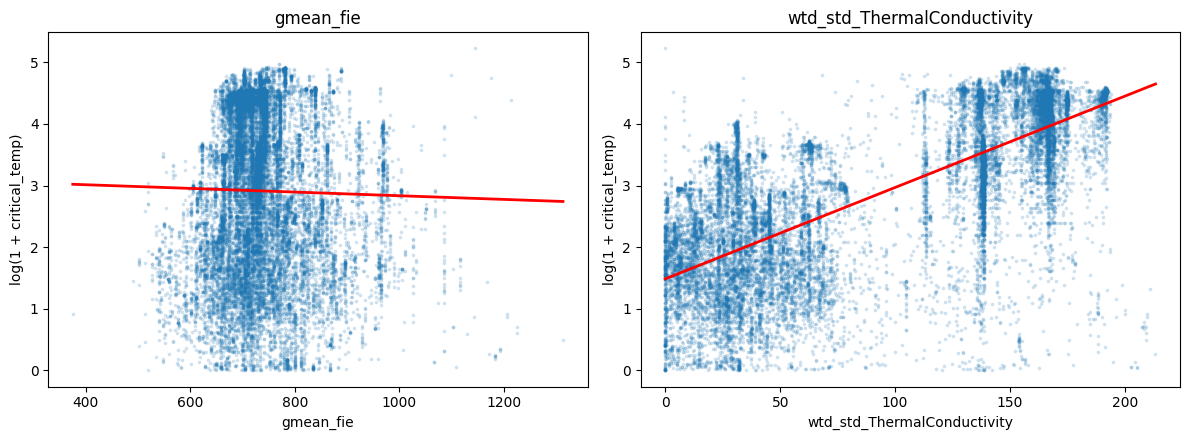

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, feat in zip(axes, [WEAK, STRONG]):
    w, b, _, mu, sigma = results[feat]
    x = df[feat].values
    xs = np.linspace(x.min(), x.max(), 100)
    ax.scatter(x, y_target, s=3, alpha=0.15)
    ax.plot(xs, w * (xs - mu) / sigma + b, color="red", lw=2)
    ax.set(title=feat, xlabel=feat, ylabel="log(1 + critical_temp)")
plt.tight_layout()
plt.savefig("figures/q134_regression_lines.png", dpi=200, bbox_inches="tight")
plt.show()